# Memory Footprint Analysis: Transformer vs. SSM Models

This notebook measures and visualizes the **GPU memory footprint** of seven language model architectures across increasing sequence lengths during the **prefill phase**:

| Model | Type | Size |
|-------|------|------|
| Phi-3-mini | Transformer | ~3.8B |
| Qwen2.5-0.5B-Instruct | Transformer | ~0.5B |
| Llama 3.2 | Transformer | ~1B |
| Mamba-790m | SSM (Mamba-1) | ~790M |
| Mamba2-780m | SSM (Mamba-2) | ~780M |
| Falcon-H1 0.5B | Hybrid SSM | ~0.5B |
| Zamba2 | Hybrid SSM | ~2.7B |

Memory is decomposed into three stacked components:
- **Model Size** — static parameter memory (constant across sequence lengths)
- **Activation Memory** — intermediate tensors during the forward pass
- **KV Cache** — key-value cache for attention layers (zero for pure SSMs)

Results are saved to `memory_footprint_rtx_ispass.png` for use as a paper figure.

In [6]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import sys

## Sequence Length Configuration

Define the per-model sequence length ranges used for profiling. Each range reflects the maximum context length the model can process before running out of GPU memory on a 24 GB RTX 3090.

In [7]:
# Define sequence lengths to test
# mamba_790m_seq_lengths = [256, 512, 1024, 2048, 4096, 8192, 16384, 24576, 32768, 40960, 49152, 57344, 65536, 73728, 81920, 90112, 98304, 106496, 114688, 122880, 131072, 139264, 147456, 155648, 200000, 220000]
mamba_790m_seq_lengths = [1024, 2048, 4096, 8192, 16384, 24576, 32768, 40960, 49152, 57344, 65536, 81920, 98304, 114688, 131072, 147456, 163840, 180224, 220000]
# mamba_1_4b_seq_lengths = [256, 512, 1024, 2048, 4096, 8192, 16384, 24576, 32768, 40960, 49152, 57344, 65536, 73728, 81920, 90112, 98304, 106496, 114688, 122880, 131072, 139264, 147456, 155648, 200000]
# mamba2_780m_seq_lengths = [256, 512, 1024, 2048, 4096, 8192, 16384, 24576, 32768, 40960, 49152, 57344, 65536, 73728, 81920, 90112, 98304, 106496, 114688, 122880, 131072, 139264, 147456, 155648, 200000, 220000]
mamba2_780m_seq_lengths = [1024, 2048, 4096, 8192, 16384, 24576, 32768, 40960, 49152, 57344, 65536, 81920, 98304, 114688, 131072, 147456, 163840, 180224, 220000]
# qwen_seq_lengths = [256, 512, 1024, 2048, 4096, 8192, 16384, 24576, 32768, 40960, 49152, 57344]
qwen_seq_lengths = [1024, 2048, 4096, 8192, 16384, 24576, 32768, 40960, 49152, 57344]
# qwen_1_5b_seq_lengths = [256, 512, 1024, 2048, 4096, 8192, 16384, 24576, 32768, 40960, 49152, 57344]
# qwen_1_5b_seq_lengths = [1024, 2048, 4096, 8192, 16384, 24576, 32768, 40960, 49152, 57344]
# zamba2_seq_lengths = [256, 512, 1024, 2048, 4096, 8192, 16384, 24576, 32768, 40960, 49152]
zamba2_seq_lengths = [1024, 2048, 4096, 8192, 16384, 24576, 32768, 40960, 49152]
# llama_3_2_seq_lengths = [256, 512, 1024, 2048, 4096, 8192, 16384, 24576, 32768, 40960, 49152, 57344, 65536]
llama_3_2_seq_lengths = [1024, 2048, 4096, 8192, 16384, 24576, 32768, 40960, 49152, 57344, 65536]
# phi3_seq_lengths = [256, 512, 1024, 2048, 4096]
phi3_seq_lengths = [1024, 2048, 4096]
falcon_h1_5b_seq_lengths = [1024, 2048, 4096, 8192, 16384, 24576, 32768, 40960, 49152, 57344, 65536, 81920, 98304, 114688, 131072, 147456, 163840]
# qwen_seq_lengths = [64, 256, 1024, 8192, 32768]
# mamba_seq_lengths = [64, 256, 1024, 8192, 32768, 65536, 131072]

## Load Data

Load the pre-collected memory profiling results from CSV. Each row records the memory breakdown for one `(model, sequence_length)` combination measured on a single GPU.

In [9]:
# Load the CSV file
csv_path = 'memory_footprints.csv'
df = pd.read_csv(csv_path)

# Create two dataframes for the two models
qwen_df = df[df['model_name'] == 'qwen25-instruct'].sort_values('seq_len')
mamba_df = df[df['model_name'] == 'mamba-790m'].sort_values('seq_len')
qwen_1_5b_df = df[df['model_name'] == 'qwen25-1.5b-instruct'].sort_values('seq_len')
mamba_1_4b_df = df[df['model_name'] == 'mamba-1.4b'].sort_values('seq_len')
mamba2_df = df[df['model_name'] == 'mamba2-780m'].sort_values('seq_len')
zamba2_df = df[df['model_name'] == 'zamba2'].sort_values('seq_len')
phi_df = df[df['model_name'] == 'phi3'].sort_values('seq_len')
llama3_2_df = df[df['model_name'] == 'llama3_2'].sort_values('seq_len')
falcon_h1_5b_df = df[df['model_name'] == 'falcon-h1-0.5b'].sort_values('seq_len')

print("Qwen data:")
print(qwen_df)
print("\nMamba data:")
print(mamba_df)
print("\nQwen 1.5B data:")
print(qwen_1_5b_df)
print("\nMamba 1.4B data:")
print(mamba_1_4b_df)
print("\nZamba2 data:")
print(zamba2_df)
print("\nPhi data:")
print(phi_df)
print("\nLlama 3.2 data:")
print(llama3_2_df)
print("\nMamba2 data:")
print(mamba2_df)
print("\nFalcon H1 0.5B data:")
print(falcon_h1_5b_df)

Qwen data:
         model_name                model_config  seq_len  batch_size  \
0   qwen25-instruct  Qwen/Qwen2.5-0.5B-Instruct      256           1   
1   qwen25-instruct  Qwen/Qwen2.5-0.5B-Instruct      512           1   
2   qwen25-instruct  Qwen/Qwen2.5-0.5B-Instruct     1024           1   
3   qwen25-instruct  Qwen/Qwen2.5-0.5B-Instruct     2048           1   
4   qwen25-instruct  Qwen/Qwen2.5-0.5B-Instruct     4096           1   
5   qwen25-instruct  Qwen/Qwen2.5-0.5B-Instruct     8192           1   
6   qwen25-instruct  Qwen/Qwen2.5-0.5B-Instruct    16384           1   
7   qwen25-instruct  Qwen/Qwen2.5-0.5B-Instruct    24576           1   
8   qwen25-instruct  Qwen/Qwen2.5-0.5B-Instruct    32768           1   
9   qwen25-instruct  Qwen/Qwen2.5-0.5B-Instruct    40960           1   
10  qwen25-instruct  Qwen/Qwen2.5-0.5B-Instruct    49152           1   
11  qwen25-instruct  Qwen/Qwen2.5-0.5B-Instruct    57344           1   

    model_size_mb  activation_memory_mb  kv_cache_mb

## Helper Functions

Utility functions used throughout the notebook:
- `get_model_data` — extracts memory breakdown for a model at each requested sequence length; fills zeros for missing entries (OOM)
- `create_arrays` — converts the per-sequence-length dict into flat arrays

In [18]:
# Create x positions for the bars with some offset between model groups
bar_width = 0.15  # Narrower bars to fit five models
seq_lengths = sorted(list(set(qwen_df['seq_len'].tolist() + mamba_df['seq_len'].tolist() + 
                             qwen_1_5b_df['seq_len'].tolist() + mamba_1_4b_df['seq_len'].tolist() + 
                             zamba2_df['seq_len'].tolist())))
x = np.arange(len(seq_lengths))

# Prepare data for plotting - function to get model data for specific sequence lengths
def get_model_data(df, seq_lengths):
    data = {}
    for seq_len in seq_lengths:
        row = df[df['seq_len'] == seq_len]
        if not row.empty:
            data[seq_len] = {
                'model_size': row['model_size_mb'].values[0],
                'activation': row['activation_memory_mb'].values[0],
                'kv_cache': row['kv_cache_mb'].values[0],
                'reserved': row['reserved_memory_mb'].values[0],
                'total': row['total_memory_mb'].values[0]
            }
        else:
            data[seq_len] = {'model_size': 0, 'activation': 0, 'kv_cache': 0, 'reserved': 0, 'total': 0}
    return data

# Function to create arrays for plotting
def create_arrays(model_data, seq_lengths):
    return {
        'model_sizes': [model_data[seq_len]['model_size'] for seq_len in seq_lengths],
        'activations': [model_data[seq_len]['activation'] for seq_len in seq_lengths],
        'kv_caches': [model_data[seq_len]['kv_cache'] for seq_len in seq_lengths],
        'reserved': [model_data[seq_len]['reserved'] for seq_len in seq_lengths],
        'totals': [model_data[seq_len]['total'] for seq_len in seq_lengths]
    }

## Visualization — Annotated Bar Chart

Stacked grouped bar chart comparing all seven models across the shared set of sequence lengths. Each group of bars represents one sequence length; within each group the bars are ordered **Phi-3-mini → Qwen → Llama → Mamba → Mamba2 → Falcon-H1 → Zamba2**. The dashed red line marks the 24 GB GPU memory limit.

All sequence lengths for final plot: [1024, 2048, 4096, 8192, 16384, 24576, 32768, 40960, 49152, 57344, 65536, 81920, 98304, 114688, 131072, 147456, 163840, 180224, 220000]


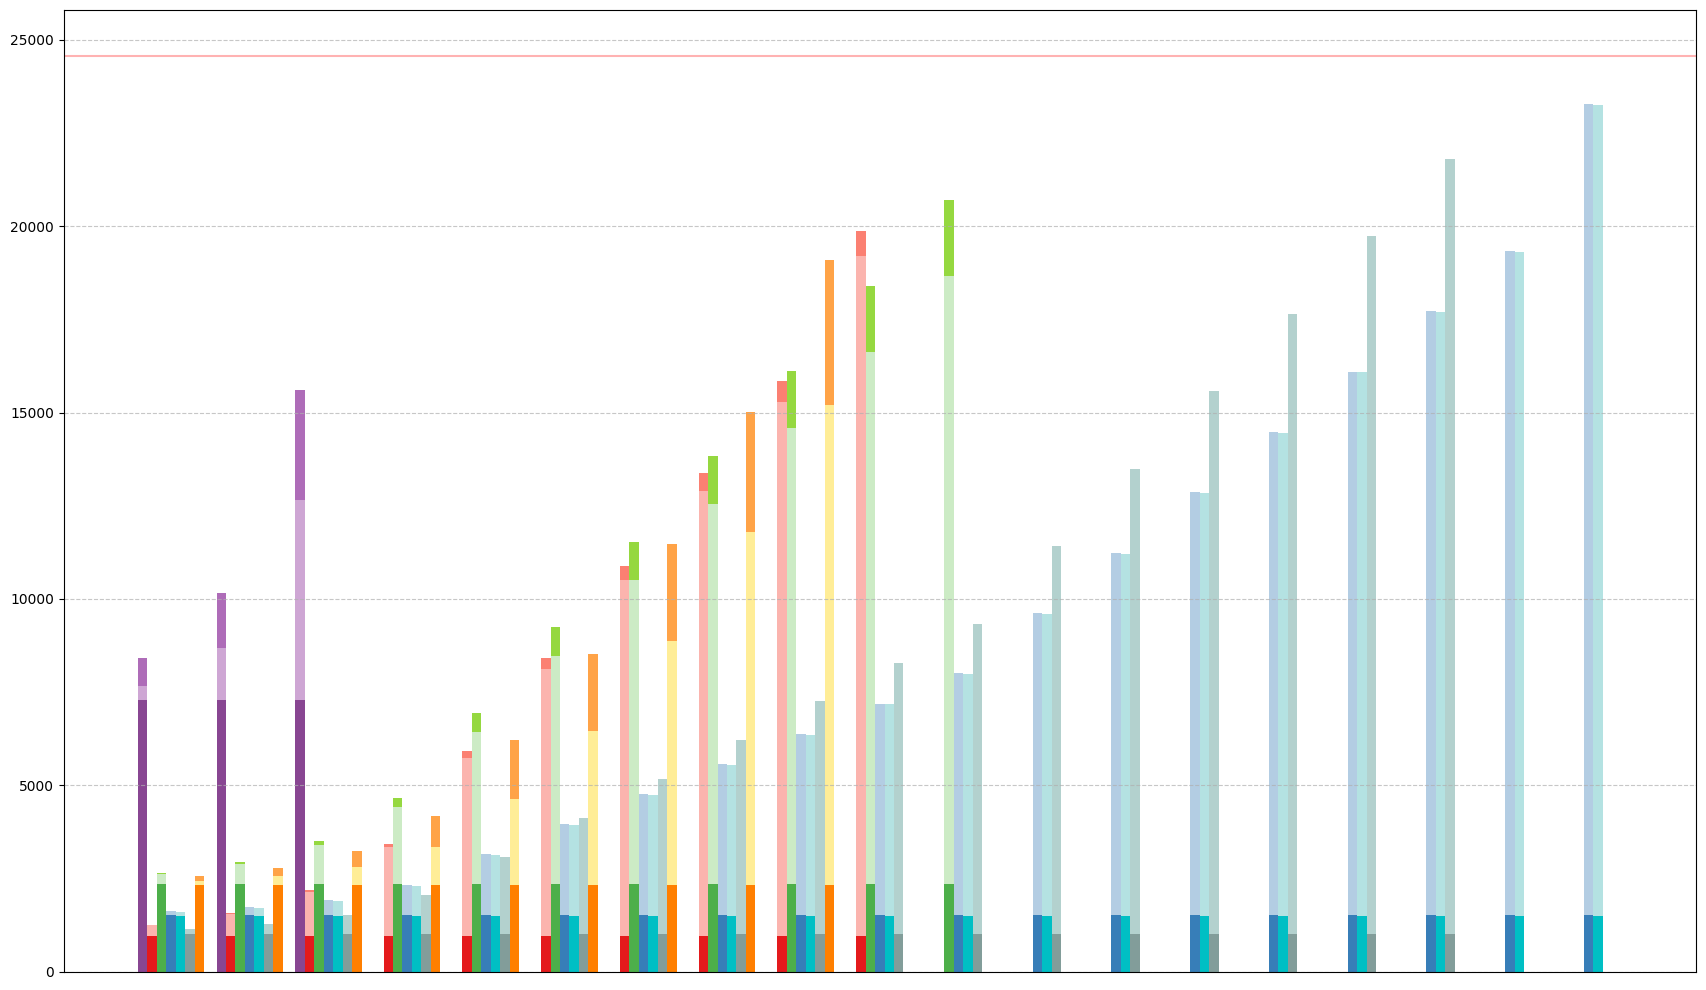

In [19]:
# Create a detailed stacked bar visualization for five models: Qwen 0.5B, Mamba-790m, Zamba2, Llama3-2B, Phi-3-mini
plt.figure(figsize=(22, 10))

# Define the specific sequence lengths we want to plot (union from cell 3)
desired_seq_lengths = [1024, 2048, 4096, 8192, 16384, 24576, 32768, 40960, 49152, 57344, 65536, 81920, 98304, 114688, 131072, 147456, 163840, 180224, 220000]

# Compose the union of all sequence lengths and filter to only desired ones
all_seq_lengths_raw = sorted(list(set(
    qwen_df['seq_len'].tolist() +
    mamba_df['seq_len'].tolist() +
    zamba2_df['seq_len'].tolist() +
    phi_df['seq_len'].tolist() +
    llama3_2_df['seq_len'].tolist() +
    mamba2_df['seq_len'].tolist()+
    falcon_h1_5b_df['seq_len'].tolist()
)))

# Filter to only include desired sequence lengths
all_seq_lengths = [seq_len for seq_len in all_seq_lengths_raw if seq_len in desired_seq_lengths]
print("All sequence lengths for final plot:", all_seq_lengths)

x = np.arange(len(all_seq_lengths))
bar_width = 0.12
gap = 0.00

# Prepare data for plotting
qwen_data = get_model_data(qwen_df, seq_lengths)
mamba_data = get_model_data(mamba_df, seq_lengths)
zamba2_data = get_model_data(zamba2_df, seq_lengths)
phi_data = get_model_data(phi_df, seq_lengths)
llama3_2_data = get_model_data(llama3_2_df, seq_lengths)
mamba2_data = get_model_data(mamba2_df, seq_lengths)  # NEW: Add Mamba2
falcon_h1_data = get_model_data(falcon_h1_5b_df, seq_lengths)


# Prepare data for plotting
qwen_arrays = create_arrays(qwen_data, all_seq_lengths)
mamba_arrays = create_arrays(mamba_data, all_seq_lengths)
zamba2_arrays = create_arrays(zamba2_data, all_seq_lengths)
phi_arrays = create_arrays(phi_data, all_seq_lengths)
llama3_2_arrays = create_arrays(llama3_2_data, all_seq_lengths)
mamba2_arrays = create_arrays(mamba2_data, all_seq_lengths)  # NEW: Add Mamba2
falcon_h1_arrays = create_arrays(falcon_h1_data, all_seq_lengths)

# Define color schemes
qwen_colors = {'model': '#E41A1C', 'activation': '#FBB4AE', 'kv': '#FB8072', 'reserved': 'red'}
mamba_colors = {'model': '#377EB8', 'activation': '#B3CDE3', 'kv': '#6BAED6', 'reserved': 'blue'}
zamba2_colors = {'model': '#FF7F00', 'activation': '#FFED97', 'kv': '#FFA347', 'reserved': 'orange'}
phi_colors = {'model': "#884692", 'activation': '#cea6d4', 'kv': '#ae6cb8', 'reserved': 'purple'}
llama3_2_colors = {'model': '#4DAF4A', 'activation': '#CCEBC5', 'kv': '#95D840', 'reserved': 'green'}
mamba2_colors = {'model': '#00BFC4', 'activation': '#B4E2E2', 'kv': '#1DE9B6', 'reserved': '#008080'}  # NEW: Add Mamba2
falcon_h1_colors = {'model': '#829D9A', 'activation': "#B3D1CE", 'kv': "#8EACA8", 'reserved': "#738886"}

# Plot stacked bars for each model with offsets
# Order: Phi3, Qwen, Llama, Mamba, Mamba2, Falcon, Zamba
plt.bar(x - 3*(bar_width+gap), phi_arrays['model_sizes'], bar_width, label='Phi-3-mini: Model Size', color=phi_colors['model'])
plt.bar(x - 3*(bar_width+gap), phi_arrays['activations'], bar_width, bottom=phi_arrays['model_sizes'], color=phi_colors['activation'])
plt.bar(x - 3*(bar_width+gap), phi_arrays['kv_caches'], bar_width, bottom=[a+b for a,b in zip(phi_arrays['model_sizes'], phi_arrays['activations'])], color=phi_colors['kv'])

plt.bar(x - 2*(bar_width+gap), qwen_arrays['model_sizes'], bar_width, label='Qwen 0.5B: Model Size', color=qwen_colors['model'])
plt.bar(x - 2*(bar_width+gap), qwen_arrays['activations'], bar_width, bottom=qwen_arrays['model_sizes'], color=qwen_colors['activation'])
plt.bar(x - 2*(bar_width+gap), qwen_arrays['kv_caches'], bar_width, bottom=[a+b for a,b in zip(qwen_arrays['model_sizes'], qwen_arrays['activations'])], color=qwen_colors['kv'])

plt.bar(x - 1*(bar_width+gap), llama3_2_arrays['model_sizes'], bar_width, label='Llama3-2B: Model Size', color=llama3_2_colors['model'])
plt.bar(x - 1*(bar_width+gap), llama3_2_arrays['activations'], bar_width, bottom=llama3_2_arrays['model_sizes'], color=llama3_2_colors['activation'])
plt.bar(x - 1*(bar_width+gap), llama3_2_arrays['kv_caches'], bar_width, bottom=[a+b for a,b in zip(llama3_2_arrays['model_sizes'], llama3_2_arrays['activations'])], color=llama3_2_colors['kv'])

plt.bar(x, mamba_arrays['model_sizes'], bar_width, label='Mamba-790m: Model Size', color=mamba_colors['model'])
plt.bar(x, mamba_arrays['activations'], bar_width, bottom=mamba_arrays['model_sizes'], color=mamba_colors['activation'])
plt.bar(x, mamba_arrays['kv_caches'], bar_width, bottom=[a+b for a,b in zip(mamba_arrays['model_sizes'], mamba_arrays['activations'])], color=mamba_colors['kv'])

plt.bar(x + 1*(bar_width+gap), mamba2_arrays['model_sizes'], bar_width, label='Mamba2: Model Size', color=mamba2_colors['model'])
plt.bar(x + 1*(bar_width+gap), mamba2_arrays['activations'], bar_width, bottom=mamba2_arrays['model_sizes'], color=mamba2_colors['activation'])
plt.bar(x + 1*(bar_width+gap), mamba2_arrays['kv_caches'], bar_width, bottom=[a+b for a,b in zip(mamba2_arrays['model_sizes'], mamba2_arrays['activations'])], color=mamba2_colors['kv'])

plt.bar(x + 2*(bar_width+gap), falcon_h1_arrays['model_sizes'], bar_width, label='Falcon-H1-5B: Model Size', color=falcon_h1_colors['model'])
plt.bar(x + 2*(bar_width+gap), falcon_h1_arrays['activations'], bar_width, bottom=falcon_h1_arrays['model_sizes'], color=falcon_h1_colors['activation'])
plt.bar(x + 2*(bar_width+gap), falcon_h1_arrays['kv_caches'], bar_width, bottom=[a+b for a,b in zip(falcon_h1_arrays['model_sizes'], falcon_h1_arrays['activations'])], color=falcon_h1_colors['kv'])

plt.bar(x + 3*(bar_width+gap), zamba2_arrays['model_sizes'], bar_width, label='Zamba2: Model Size', color=zamba2_colors['model'])
plt.bar(x + 3*(bar_width+gap), zamba2_arrays['activations'], bar_width, bottom=zamba2_arrays['model_sizes'], color=zamba2_colors['activation'])
plt.bar(x + 3*(bar_width+gap), zamba2_arrays['kv_caches'], bar_width, bottom=[a+b for a,b in zip(zamba2_arrays['model_sizes'], zamba2_arrays['activations'])], color=zamba2_colors['kv'])

# # Plot reserved memory lines
# plot_reserved_memory(x, phi_arrays, all_seq_lengths, -3*(bar_width+gap), phi_colors['reserved'], 'Phi-3-mini: Reserved Memory')
# plot_reserved_memory(x, qwen_arrays, all_seq_lengths, -2*(bar_width+gap), qwen_colors['reserved'], 'Qwen 0.5B: Reserved Memory')
# plot_reserved_memory(x, llama3_2_arrays, all_seq_lengths, -1*(bar_width+gap), llama3_2_colors['reserved'], 'Llama3-2B: Reserved Memory')
# plot_reserved_memory(x, mamba_arrays, all_seq_lengths, 0, mamba_colors['reserved'], 'Mamba-790m: Reserved Memory')
# plot_reserved_memory(x, mamba2_arrays, all_seq_lengths, 1*(bar_width+gap), mamba2_colors['reserved'], 'Mamba2: Reserved Memory')
# plot_reserved_memory(x, falcon_h1_arrays, all_seq_lengths, 2*(bar_width+gap), falcon_h1_colors['reserved'], 'Falcon-H1-5B: Reserved Memory')
# plot_reserved_memory(x, zamba2_arrays, all_seq_lengths, 3*(bar_width+gap), zamba2_colors['reserved'], 'Zamba2: Reserved Memory')

# Add a horizontal line at 24GB to indicate GPU memory limit
plt.axhline(y=24576, color='red', linestyle='-', alpha=0.3, label='24GB GPU Memory Limit')

# Remove ticks
plt.xticks([])
# plt.yticks([])

plt.grid(axis='y', linestyle='--', alpha=0.7)

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

model_size_legend = [
    Patch(facecolor=phi_colors['model'], label='Phi-3-mini: Model Size'),
    Patch(facecolor=qwen_colors['model'], label='Qwen 0.5B: Model Size'),
    Patch(facecolor=llama3_2_colors['model'], label='Llama3-2B: Model Size'),
    Patch(facecolor=mamba_colors['model'], label='Mamba-790m: Model Size'),
    Patch(facecolor=mamba2_colors['model'], label='Mamba2: Model Size'),
    Patch(facecolor=falcon_h1_colors['model'], label='Falcon-H1-5B: Model Size'),
    Patch(facecolor=zamba2_colors['model'], label='Zamba2: Model Size')
]

activation_legend = [
    Patch(facecolor=phi_colors['activation'], label='Phi-3-mini: Activation'),
    Patch(facecolor=qwen_colors['activation'], label='Qwen 0.5B: Activation'),
    Patch(facecolor=llama3_2_colors['activation'], label='Llama3-2B: Activation'),
    Patch(facecolor=mamba_colors['activation'], label='Mamba-790m: Activation'),
    Patch(facecolor=mamba2_colors['activation'], label='Mamba2: Activation'),
    Patch(facecolor=falcon_h1_colors['activation'], label='Falcon-H1-5B: Activation'),
    Patch(facecolor=zamba2_colors['activation'], label='Zamba2: Activation')
]

kv_cache_legend = [
    Patch(facecolor=phi_colors['kv'], label='Phi-3-mini: KV Cache'),
    Patch(facecolor=qwen_colors['kv'], label='Qwen 0.5B: KV Cache'),
    Patch(facecolor=llama3_2_colors['kv'], label='Llama3-2B: KV Cache'),
    Patch(facecolor=mamba_colors['kv'], label='Mamba-790m: KV Cache'),
    Patch(facecolor=mamba2_colors['kv'], label='Mamba2: KV Cache'),
    Patch(facecolor=falcon_h1_colors['kv'], label='Falcon-H1-5B: KV Cache'),
    Patch(facecolor=zamba2_colors['kv'], label='Zamba2: KV Cache')
]

reserved_legend = [
    Line2D([0], [0], color=phi_colors['reserved'], linestyle='--', marker='o', label='Phi-3-mini: Reserved'),
    Line2D([0], [0], color=qwen_colors['reserved'], linestyle='--', marker='o', label='Qwen 0.5B: Reserved'),
    Line2D([0], [0], color=llama3_2_colors['reserved'], linestyle='--', marker='o', label='Llama3-2B: Reserved'),
    Line2D([0], [0], color=mamba_colors['reserved'], linestyle='--', marker='o', label='Mamba-790m: Reserved'),
    Line2D([0], [0], color=mamba2_colors['reserved'], linestyle='--', marker='o', label='Mamba2: Reserved'),
    Line2D([0], [0], color=falcon_h1_colors['reserved'], linestyle='--', marker='o', label='Falcon-H1-5B: Reserved'),
    Line2D([0], [0], color=zamba2_colors['reserved'], linestyle='--', marker='o', label='Zamba2: Reserved')
]

other_legend = [
    Line2D([0], [0], color='red', linestyle='-', alpha=0.3, label='24GB GPU Memory Limit')
]

plt.tight_layout(rect=[0, 0, 0.78, 1])
# plt.savefig('plot_model/memory_footprint_rtx_ispass.png', dpi=300, bbox_inches='tight')
plt.show()


## Publication Figure

Clean version of the same plot — y-axis tick labels removed for use as a paper figure. The output is saved to `memory_footprint_rtx_ispass.png` at 300 DPI.

All sequence lengths for final plot: [1024, 2048, 4096, 8192, 16384, 24576, 32768, 40960, 49152, 57344, 65536, 81920, 98304, 114688, 131072, 147456, 163840, 180224, 220000]


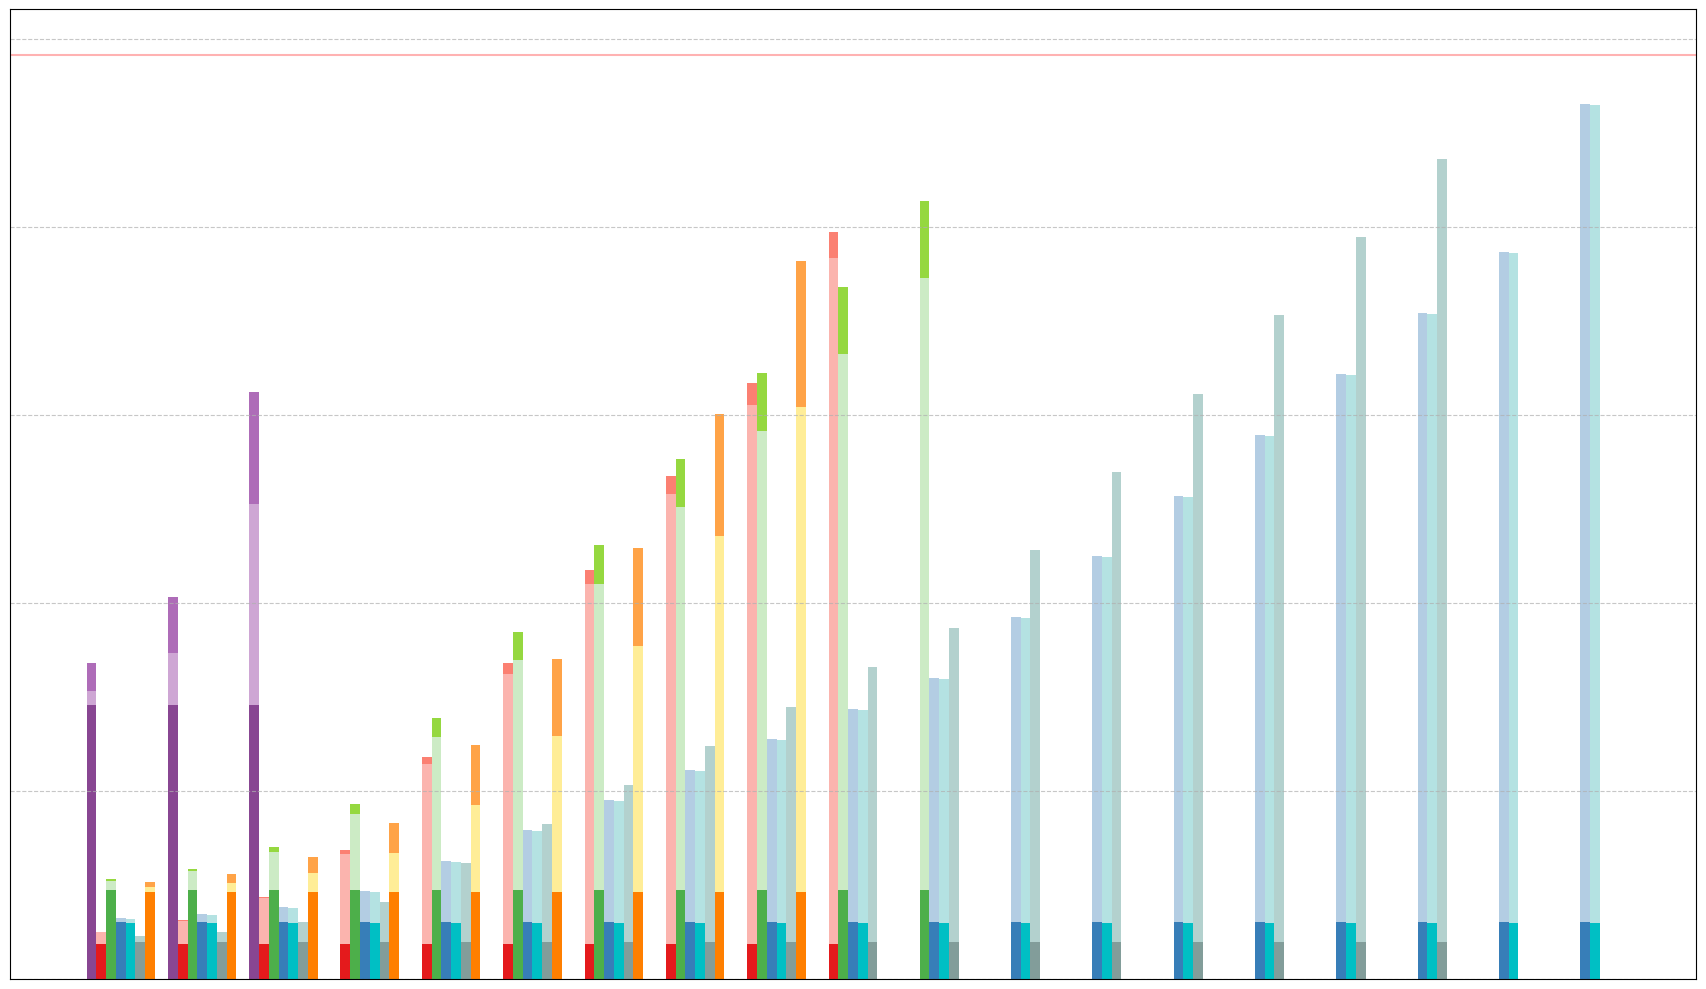

In [21]:
# Create a detailed stacked bar visualization for five models: Qwen 0.5B, Mamba-790m, Zamba2, Llama3-2B, Phi-3-mini
plt.figure(figsize=(22, 10))

# Define the specific sequence lengths we want to plot (union from cell 3)
desired_seq_lengths = [1024, 2048, 4096, 8192, 16384, 24576, 32768, 40960, 49152, 57344, 65536, 81920, 98304, 114688, 131072, 147456, 163840, 180224, 220000]

# Compose the union of all sequence lengths and filter to only desired ones
all_seq_lengths_raw = sorted(list(set(
    qwen_df['seq_len'].tolist() +
    mamba_df['seq_len'].tolist() +
    zamba2_df['seq_len'].tolist() +
    phi_df['seq_len'].tolist() +
    llama3_2_df['seq_len'].tolist() +
    mamba2_df['seq_len'].tolist()+
    falcon_h1_5b_df['seq_len'].tolist()
)))

# Filter to only include desired sequence lengths
all_seq_lengths = [seq_len for seq_len in all_seq_lengths_raw if seq_len in desired_seq_lengths]
print("All sequence lengths for final plot:", all_seq_lengths)

x = np.arange(len(all_seq_lengths))
bar_width = 0.12
gap = 0.00

# Prepare data for plotting
qwen_data = get_model_data(qwen_df, seq_lengths)
mamba_data = get_model_data(mamba_df, seq_lengths)
zamba2_data = get_model_data(zamba2_df, seq_lengths)
phi_data = get_model_data(phi_df, seq_lengths)
llama3_2_data = get_model_data(llama3_2_df, seq_lengths)
mamba2_data = get_model_data(mamba2_df, seq_lengths)  # NEW: Add Mamba2
falcon_h1_data = get_model_data(falcon_h1_5b_df, seq_lengths)


# Prepare data for plotting
qwen_arrays = create_arrays(qwen_data, all_seq_lengths)
mamba_arrays = create_arrays(mamba_data, all_seq_lengths)
zamba2_arrays = create_arrays(zamba2_data, all_seq_lengths)
phi_arrays = create_arrays(phi_data, all_seq_lengths)
llama3_2_arrays = create_arrays(llama3_2_data, all_seq_lengths)
mamba2_arrays = create_arrays(mamba2_data, all_seq_lengths)  # NEW: Add Mamba2
falcon_h1_arrays = create_arrays(falcon_h1_data, all_seq_lengths)

# Define color schemes
qwen_colors = {'model': '#E41A1C', 'activation': '#FBB4AE', 'kv': '#FB8072', 'reserved': 'red'}
mamba_colors = {'model': '#377EB8', 'activation': '#B3CDE3', 'kv': '#6BAED6', 'reserved': 'blue'}
zamba2_colors = {'model': '#FF7F00', 'activation': '#FFED97', 'kv': '#FFA347', 'reserved': 'orange'}
phi_colors = {'model': "#884692", 'activation': '#cea6d4', 'kv': '#ae6cb8', 'reserved': 'purple'}
llama3_2_colors = {'model': '#4DAF4A', 'activation': '#CCEBC5', 'kv': '#95D840', 'reserved': 'green'}
mamba2_colors = {'model': '#00BFC4', 'activation': '#B4E2E2', 'kv': '#1DE9B6', 'reserved': '#008080'}  # NEW: Add Mamba2
falcon_h1_colors = {'model': '#829D9A', 'activation': "#B3D1CE", 'kv': "#8EACA8", 'reserved': "#738886"}

# Plot stacked bars for each model with offsets
# Order: Phi3, Qwen, Llama, Mamba, Mamba2, Falcon, Zamba
plt.bar(x - 3*(bar_width+gap), phi_arrays['model_sizes'], bar_width, label='Phi-3-mini: Model Size', color=phi_colors['model'])
plt.bar(x - 3*(bar_width+gap), phi_arrays['activations'], bar_width, bottom=phi_arrays['model_sizes'], color=phi_colors['activation'])
plt.bar(x - 3*(bar_width+gap), phi_arrays['kv_caches'], bar_width, bottom=[a+b for a,b in zip(phi_arrays['model_sizes'], phi_arrays['activations'])], color=phi_colors['kv'])

plt.bar(x - 2*(bar_width+gap), qwen_arrays['model_sizes'], bar_width, label='Qwen 0.5B: Model Size', color=qwen_colors['model'])
plt.bar(x - 2*(bar_width+gap), qwen_arrays['activations'], bar_width, bottom=qwen_arrays['model_sizes'], color=qwen_colors['activation'])
plt.bar(x - 2*(bar_width+gap), qwen_arrays['kv_caches'], bar_width, bottom=[a+b for a,b in zip(qwen_arrays['model_sizes'], qwen_arrays['activations'])], color=qwen_colors['kv'])

plt.bar(x - 1*(bar_width+gap), llama3_2_arrays['model_sizes'], bar_width, label='Llama3-2B: Model Size', color=llama3_2_colors['model'])
plt.bar(x - 1*(bar_width+gap), llama3_2_arrays['activations'], bar_width, bottom=llama3_2_arrays['model_sizes'], color=llama3_2_colors['activation'])
plt.bar(x - 1*(bar_width+gap), llama3_2_arrays['kv_caches'], bar_width, bottom=[a+b for a,b in zip(llama3_2_arrays['model_sizes'], llama3_2_arrays['activations'])], color=llama3_2_colors['kv'])

plt.bar(x, mamba_arrays['model_sizes'], bar_width, label='Mamba-790m: Model Size', color=mamba_colors['model'])
plt.bar(x, mamba_arrays['activations'], bar_width, bottom=mamba_arrays['model_sizes'], color=mamba_colors['activation'])
plt.bar(x, mamba_arrays['kv_caches'], bar_width, bottom=[a+b for a,b in zip(mamba_arrays['model_sizes'], mamba_arrays['activations'])], color=mamba_colors['kv'])

plt.bar(x + 1*(bar_width+gap), mamba2_arrays['model_sizes'], bar_width, label='Mamba2: Model Size', color=mamba2_colors['model'])
plt.bar(x + 1*(bar_width+gap), mamba2_arrays['activations'], bar_width, bottom=mamba2_arrays['model_sizes'], color=mamba2_colors['activation'])
plt.bar(x + 1*(bar_width+gap), mamba2_arrays['kv_caches'], bar_width, bottom=[a+b for a,b in zip(mamba2_arrays['model_sizes'], mamba2_arrays['activations'])], color=mamba2_colors['kv'])

plt.bar(x + 2*(bar_width+gap), falcon_h1_arrays['model_sizes'], bar_width, label='Falcon-H1-5B: Model Size', color=falcon_h1_colors['model'])
plt.bar(x + 2*(bar_width+gap), falcon_h1_arrays['activations'], bar_width, bottom=falcon_h1_arrays['model_sizes'], color=falcon_h1_colors['activation'])
plt.bar(x + 2*(bar_width+gap), falcon_h1_arrays['kv_caches'], bar_width, bottom=[a+b for a,b in zip(falcon_h1_arrays['model_sizes'], falcon_h1_arrays['activations'])], color=falcon_h1_colors['kv'])

plt.bar(x + 3*(bar_width+gap), zamba2_arrays['model_sizes'], bar_width, label='Zamba2: Model Size', color=zamba2_colors['model'])
plt.bar(x + 3*(bar_width+gap), zamba2_arrays['activations'], bar_width, bottom=zamba2_arrays['model_sizes'], color=zamba2_colors['activation'])
plt.bar(x + 3*(bar_width+gap), zamba2_arrays['kv_caches'], bar_width, bottom=[a+b for a,b in zip(zamba2_arrays['model_sizes'], zamba2_arrays['activations'])], color=zamba2_colors['kv'])

# # Plot reserved memory lines
# plot_reserved_memory(x, phi_arrays, all_seq_lengths, -3*(bar_width+gap), phi_colors['reserved'], 'Phi-3-mini: Reserved Memory')
# plot_reserved_memory(x, qwen_arrays, all_seq_lengths, -2*(bar_width+gap), qwen_colors['reserved'], 'Qwen 0.5B: Reserved Memory')
# plot_reserved_memory(x, llama3_2_arrays, all_seq_lengths, -1*(bar_width+gap), llama3_2_colors['reserved'], 'Llama3-2B: Reserved Memory')
# plot_reserved_memory(x, mamba_arrays, all_seq_lengths, 0, mamba_colors['reserved'], 'Mamba-790m: Reserved Memory')
# plot_reserved_memory(x, mamba2_arrays, all_seq_lengths, 1*(bar_width+gap), mamba2_colors['reserved'], 'Mamba2: Reserved Memory')
# plot_reserved_memory(x, falcon_h1_arrays, all_seq_lengths, 2*(bar_width+gap), falcon_h1_colors['reserved'], 'Falcon-H1-5B: Reserved Memory')
# plot_reserved_memory(x, zamba2_arrays, all_seq_lengths, 3*(bar_width+gap), zamba2_colors['reserved'], 'Zamba2: Reserved Memory')

# Add a horizontal line at 24GB to indicate GPU memory limit
plt.axhline(y=24576, color='red', linestyle='-', alpha=0.3, label='24GB GPU Memory Limit')

# Remove ticks
plt.xticks([])
# plt.yticks([])
plt.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)

plt.grid(axis='y', linestyle='--', alpha=0.7)

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

model_size_legend = [
    Patch(facecolor=phi_colors['model'], label='Phi-3-mini: Model Size'),
    Patch(facecolor=qwen_colors['model'], label='Qwen 0.5B: Model Size'),
    Patch(facecolor=llama3_2_colors['model'], label='Llama3-2B: Model Size'),
    Patch(facecolor=mamba_colors['model'], label='Mamba-790m: Model Size'),
    Patch(facecolor=mamba2_colors['model'], label='Mamba2: Model Size'),
    Patch(facecolor=falcon_h1_colors['model'], label='Falcon-H1-5B: Model Size'),
    Patch(facecolor=zamba2_colors['model'], label='Zamba2: Model Size')
]

activation_legend = [
    Patch(facecolor=phi_colors['activation'], label='Phi-3-mini: Activation'),
    Patch(facecolor=qwen_colors['activation'], label='Qwen 0.5B: Activation'),
    Patch(facecolor=llama3_2_colors['activation'], label='Llama3-2B: Activation'),
    Patch(facecolor=mamba_colors['activation'], label='Mamba-790m: Activation'),
    Patch(facecolor=mamba2_colors['activation'], label='Mamba2: Activation'),
    Patch(facecolor=falcon_h1_colors['activation'], label='Falcon-H1-5B: Activation'),
    Patch(facecolor=zamba2_colors['activation'], label='Zamba2: Activation')
]

kv_cache_legend = [
    Patch(facecolor=phi_colors['kv'], label='Phi-3-mini: KV Cache'),
    Patch(facecolor=qwen_colors['kv'], label='Qwen 0.5B: KV Cache'),
    Patch(facecolor=llama3_2_colors['kv'], label='Llama3-2B: KV Cache'),
    Patch(facecolor=mamba_colors['kv'], label='Mamba-790m: KV Cache'),
    Patch(facecolor=mamba2_colors['kv'], label='Mamba2: KV Cache'),
    Patch(facecolor=falcon_h1_colors['kv'], label='Falcon-H1-5B: KV Cache'),
    Patch(facecolor=zamba2_colors['kv'], label='Zamba2: KV Cache')
]

reserved_legend = [
    Line2D([0], [0], color=phi_colors['reserved'], linestyle='--', marker='o', label='Phi-3-mini: Reserved'),
    Line2D([0], [0], color=qwen_colors['reserved'], linestyle='--', marker='o', label='Qwen 0.5B: Reserved'),
    Line2D([0], [0], color=llama3_2_colors['reserved'], linestyle='--', marker='o', label='Llama3-2B: Reserved'),
    Line2D([0], [0], color=mamba_colors['reserved'], linestyle='--', marker='o', label='Mamba-790m: Reserved'),
    Line2D([0], [0], color=mamba2_colors['reserved'], linestyle='--', marker='o', label='Mamba2: Reserved'),
    Line2D([0], [0], color=falcon_h1_colors['reserved'], linestyle='--', marker='o', label='Falcon-H1-5B: Reserved'),
    Line2D([0], [0], color=zamba2_colors['reserved'], linestyle='--', marker='o', label='Zamba2: Reserved')
]

other_legend = [
    Line2D([0], [0], color='red', linestyle='-', alpha=0.3, label='24GB GPU Memory Limit')
]

plt.tight_layout(rect=[0, 0, 0.78, 1])
plt.savefig('memory_footprint_rtx_ispass.png', dpi=300, bbox_inches='tight')
plt.show()
